In [2]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm

__一、画AIA图像+ AIA GOES曲线__

读取GOES数据

In [2]:
import netCDF4 as nc
ff=nc.Dataset(r'D:\Learning\PHD1st\magnetic_reconnecion\data\GOES\sci_exis-l1b-sfxr_g16_d20240618_v0-0-1.nc' )
print(ff.variables.keys()) 

dict_keys(['irradiance_xrsa1', 'irradiance_xrsa2', 'primary_xrsa', 'irradiance_xrsb1', 'irradiance_xrsb2', 'primary_xrsb', 'xrs_ratio', 'corrected_current_xrsa_1', 'corrected_current_xrsa_2', 'corrected_current_xrsa_3', 'corrected_current_xrsa_4', 'corrected_current_xrsb_1', 'corrected_current_xrsb_2', 'corrected_current_xrsb_3', 'corrected_current_xrsb_4', 'dispersion_angle', 'crossdispersion_angle', 'sc_power_side', 'exis_flight_model', 'exis_configuration_id', 'xrs_runctrlmd', 'integration_time', 'exs_sl_pwr_ena', 'asic1_temperature', 'asic2_temperature', 'invalid_flags', 'xrs_det_chg', 'xrs_mode', 'sps_obs_time', 'sps_int_time', 'sps_temperature', 'sps_det_chg', 'num_angle_pairs', 'yaw_flip_flag', 'au_factor', 'quality_flags', 'time', 'packet_count', 'fov_unknown', 'fov_eclipse', 'fov_lunar_transit', 'fov_planet_transit', 'fov_off_point', 'quaternion_Q0', 'quaternion_Q1', 'quaternion_Q2', 'quaternion_Q3', 'ecef_X', 'ecef_Y', 'ecef_Z', 'solar_array_current', 'SC_eclipse_flag', 'prod

In [3]:
#这里dir1是pre_131.sav的目录对应0-31，dir2是131.sav的目录对应32-132，exptime是长148的观测时间
def aia_intensity_curve(dir1,dir2,exptime,wavelenth):
    from scipy.io import readsav
    #这部分先把数据读入进来
    matrices=[]
    data1=readsav(dir1)
    matrix_struct=data1['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    matrices=matrices[69:]
    data2=readsav(dir2)
    matrix_struct=data2['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    #计算平均强度
    intensity=np.zeros(133)
    for i in range(133):
        intensity[i]=np.average(matrices[i])
    #这里去掉曝光时间不一致的点，131和193单独处理
    if wavelenth=='131' or '193':
        threshold=2.90 if wavelenth=='131' else 1.99
        #print(threshold)
        intensity[exptime[:133]<threshold]=np.nan
        #把去掉的点用插值函数补上
        x=np.arange(133)
        valid_x=x[~np.isnan(intensity)]
        valid_intensity=intensity[~np.isnan(intensity)]
        f=interp1d(valid_x,valid_intensity,kind='linear')
        intensity[np.isnan(intensity)]=f(x[np.isnan(intensity)])
    #归一化
    intensity=(intensity-np.min(intensity))/(np.max(intensity)-np.min(intensity))
    return intensity

AIA强度数据

In [4]:
intensity=np.zeros((7,133))
name_list=['.94','131','171','193','211','304','335']

for i in range(7):
    file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'\*.fits')
    exptime=np.zeros(len(file_list))
    for j in range(len(file_list)):
        rsm=fits.open(file_list[j])
        exptime[j]=rsm[1].header['EXPTIME']

    dir1=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\pre_'+name_list[i]+'.sav'
    dir2=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'.sav'
    intensity[i,:]=aia_intensity_curve(dir1,dir2,exptime[:133],name_list[i])
    #print(exptime[:133])

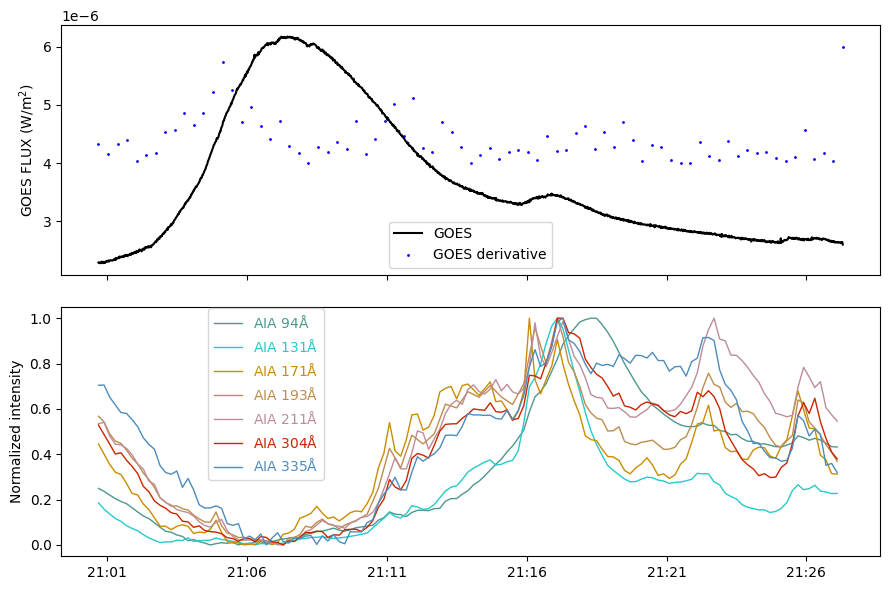

In [5]:
from scipy.interpolate import splprep, splev
from scipy.ndimage import zoom
corr_x=np.zeros(6)
#第一个时刻对应21：00：42，最后一个时刻对应21：27：06
for i in range(len(corr_x)):
    corr_x[i]=(i*300+18)/12
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,6), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
#y为GOES值
goes_x=np.linspace(0,133,1585)
goes_y=ff.variables['irradiance_xrsb1'][75642:75642+1585]
#求导，缩并
dy_dx=np.gradient(goes_y,goes_x)
dy_dx_reduced=zoom(dy_dx,0.05)

ax1.plot(goes_x,goes_y,color='black',label='GOES')
der_goes=abs(dy_dx_reduced)
der_goes2=(der_goes-np.min(der_goes))/(np.max(der_goes)-np.min(der_goes))
ax1.scatter(np.linspace(0,133,len(dy_dx_reduced)),(der_goes2+2)*1e-6*2,color='blue',s=1,label='GOES derivative')
ax1.set_ylabel('GOES FLUX (W/m$^2$)')

handles1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(handles1, labels1, loc='best')

name_list=['AIA 94$\mathrm{\AA}$','AIA 131$\mathrm{\AA}$',
           'AIA 171$\mathrm{\AA}$','AIA 193$\mathrm{\AA}$',
           'AIA 211$\mathrm{\AA}$','AIA 304$\mathrm{\AA}$','AIA 335$\mathrm{\AA}$']
lines=[]
linstyle=['-','-']

color=[]
color_list=['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335']
for i in range(7):
    cmap=plt.get_cmap(color_list[i])
    middle_color=cmap(0.55)
    color.append(middle_color)
    
#color=['green','orange','deepskyblue','blue','red','purple','brown']

for i in range(7):
    line,=ax2.plot(intensity[i,:],color=color[i],label=name_list[i],linewidth=1,linestyle=linstyle[i%2])
    lines.append(line)
legend=ax2.legend(loc='center', bbox_to_anchor=(0.25, 0.65))
for text,line in zip(legend.get_texts(),lines):
    #print(line.get_color())
    text.set_color(line.get_color())
ax2.set_ylabel('Normalized intensity')
ax2.set_xticks(ticks=corr_x,labels=['21:01','21:06','21:11','21:16','21:21','21:26'])
plt.tight_layout()
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\intensity_curve.pdf',format='pdf')

AIA图像数据

In [6]:
map1=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210908Z.131.image_lev1.fits')
map2=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211344Z.131.image_lev1.fits')
map3=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211820Z.131.image_lev1.fits')
map4=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212244Z.131.image_lev1.fits')
map5=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212620Z.131.image_lev1.fits')
map6=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\171\aia.lev1_euv_12s.2024-06-18T211822Z.171.image_lev1.fits')

Text(0.02, 0.93, '(a)            AIA131 21:07:08')

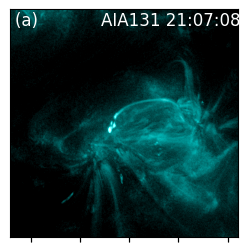

In [7]:
fig=plt.figure(figsize=(9,6))
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
gs=gridspec.GridSpec(6,9,wspace=0.1,hspace=0.05)

smap1=map5.submap(bottom_left,top_right=top_right)
ax1=fig.add_subplot(gs[0:3,0:3],projection=smap1)
ax1.set_xlabel('X(arcsecs)')
ax1.set_ylabel('Y(arcsecs)')
ax1.tick_params(axis='x',which='both',bottom=True,top=False,labeltop=False)
ax1.tick_params(axis='y',right=False,labelright=False)
norm=smap1.plot_settings['norm']
norm.vmin,norm.vmax=np.percentile(smap1.data,[20,99.9999])
im1=ax1.imshow(smap1.data,norm=norm,cmap=smap1.plot_settings['cmap'],origin='lower')
ax1.text(0.02,0.93,'(a)            AIA131 21:07:08',color='white',transform=ax1.transAxes,fontsize=12)
#cbar=fig.colorbar(im1,ax=ax1)

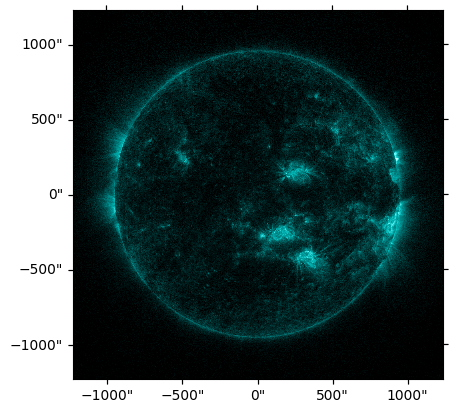

In [45]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize,LogNorm
fig = plt.figure()
ax = fig.add_subplot(projection=map5)
old_norm=map5.plot_settings['norm']
old_norm.vmin=0.01
old_norm.vmax=2000
map5.plot(axes=ax,norm=old_norm)

# 根据原始 norm 类型，生成新的 norm

# 去掉 xlabel 和 ylabel
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.coords[0].grid(draw_grid=False)
ax.coords[1].grid(draw_grid=False)

In [44]:
old_norm=map4.plot_settings['norm']
print(type(old_norm))

<class 'astropy.visualization.mpl_normalize.ImageNormalize'>


Text(0.02, 0.93, '(f)    AIA 171  21:18:21 UT')

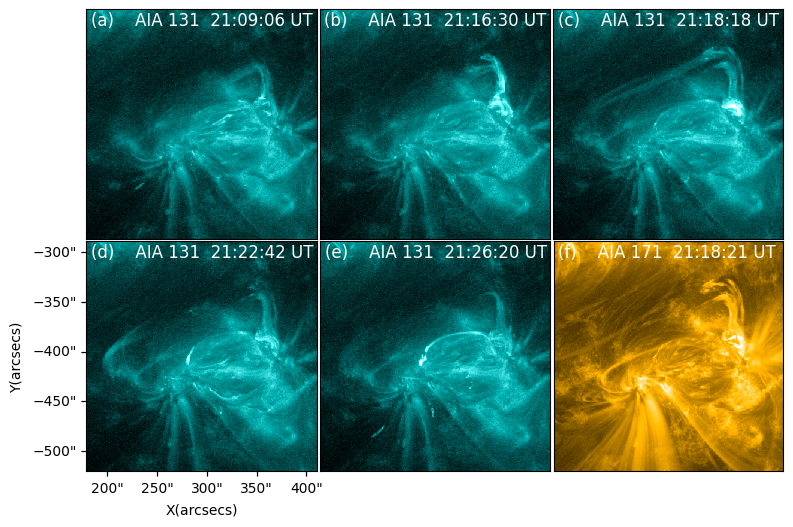

In [7]:
fig=plt.figure(figsize=(9,6))

bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
gs=gridspec.GridSpec(2,3,wspace=0.01,hspace=0.012)

map_all=[map1,map2,map3,map4,map5,map6]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

ax_all=[]
for i in range(6):
    ax=fig.add_subplot(gs[i],projection=smap_all[i])
    ax_all.append(ax)
    #设置vmin vmax

    if i!=5:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=2000
        smap_all[i].plot(axes=ax,norm=old_norm)
    else:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=5000
        smap_all[i].plot(axes=ax)

    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第四张图加X Y轴
    if i == 3:   # 左下角
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X(arcsecs)',labelpad=1.1)
        ax.set_ylabel('Y(arcsecs)',labelpad=1.1)
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)       
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

ax_all[0].text(0.02,0.93,'(a)    AIA 131  21:09:06 UT',color='white',transform=ax_all[0].transAxes,fontsize=12)
ax_all[1].text(0.02,0.93,'(b)    AIA 131  21:16:30 UT',color='white',transform=ax_all[1].transAxes,fontsize=12)
ax_all[2].text(0.02,0.93,'(c)    AIA 131  21:18:18 UT',color='white',transform=ax_all[2].transAxes,fontsize=12)
ax_all[3].text(0.02,0.93,'(d)    AIA 131  21:22:42 UT',color='white',transform=ax_all[3].transAxes,fontsize=12)
ax_all[4].text(0.02,0.93,'(e)    AIA 131  21:26:20 UT',color='white',transform=ax_all[4].transAxes,fontsize=12)
ax_all[5].text(0.02,0.93,'(f)    AIA 171  21:18:21 UT',color='white',transform=ax_all[5].transAxes,fontsize=12)


In [10]:
a=smap_all[2].data


C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:15: RuntimeWarning: divide by zero encountered in log10
  ax1.imshow(np.log10(smap1.data),cmap=smap1.plot_settings['cmap'],origin='lower')
C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:15: RuntimeWarning: invalid value encountered in log10
  ax1.imshow(np.log10(smap1.data),cmap=smap1.plot_settings['cmap'],origin='lower')
C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:20: RuntimeWarning: divide by zero encountered in log10
  ax2.imshow(np.log10(smap2.data),cmap=smap2.plot_settings['cmap'],origin='lower')
C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:20: RuntimeWarning: invalid value encountered in log10
  ax2.imshow(np.log10(smap2.data),cmap=smap2.plot_settings['cmap'],origin='lower')
C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:25: RuntimeWarning: divide by zero encountered in log10
  ax3.imshow(np.log10(smap3.data),cmap=smap3.plot_settings['cmap'],origin='

Text(0.2, 0.93, '(f) AIA171 21:07:08')

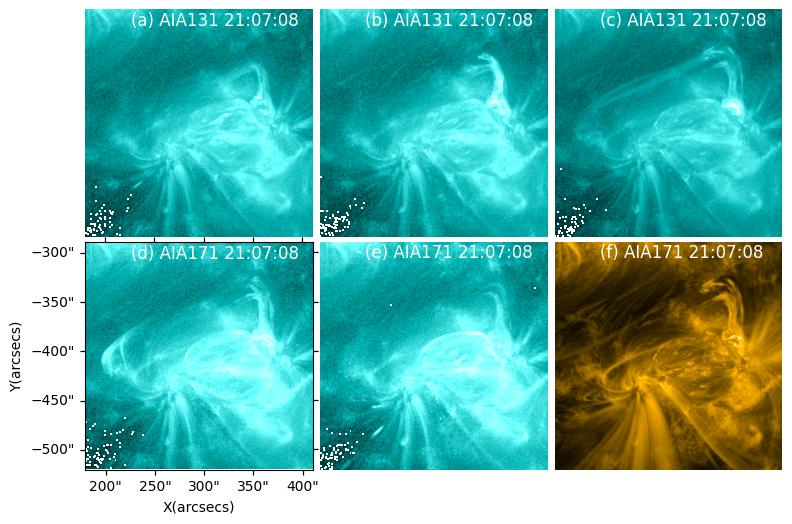

In [93]:
fig=plt.figure(figsize=(9,6))
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
gs=gridspec.GridSpec(6,9,wspace=0.1,hspace=0.05)

smap1=map1.submap(bottom_left,top_right=top_right)
smap2=map2.submap(bottom_left,top_right=top_right)
smap3=map3.submap(bottom_left,top_right=top_right)
smap4=map4.submap(bottom_left,top_right=top_right)
smap5=map5.submap(bottom_left,top_right=top_right)
smap6=map6.submap(bottom_left,top_right=top_right)

ax1=fig.add_subplot(gs[0:3,0:3],projection=smap1)
ax1.set_axis_off()
ax1.imshow(np.log10(smap1.data),cmap=smap1.plot_settings['cmap'],origin='lower')
ax1.text(0.2,0.93,'(a) AIA131 21:07:08',color='white',transform=ax1.transAxes,fontsize=12)

ax2=fig.add_subplot(gs[0:3,3:6],projection=smap2)
ax2.set_axis_off()
ax2.imshow(np.log10(smap2.data),cmap=smap2.plot_settings['cmap'],origin='lower')
ax2.text(0.2,0.93,'(b) AIA131 21:07:08',color='white',transform=ax2.transAxes,fontsize=12)

ax3=fig.add_subplot(gs[0:3,6:9],projection=smap3)
ax3.set_axis_off()
ax3.imshow(np.log10(smap3.data),cmap=smap3.plot_settings['cmap'],origin='lower')
ax3.text(0.2,0.93,'(c) AIA131 21:07:08',color='white',transform=ax3.transAxes,fontsize=12)

ax4=fig.add_subplot(gs[3:6,0:3],projection=smap4)
#ax4.set_axis_off()
ax4.set_xlabel('X(arcsecs)')
ax4.set_ylabel('Y(arcsecs)')
ax4.imshow(np.log10(smap4.data),cmap=smap4.plot_settings['cmap'],origin='lower')
ax4.text(0.2,0.93,'(d) AIA171 21:07:08',color='white',transform=ax4.transAxes,fontsize=12)

ax5=fig.add_subplot(gs[3:6,3:6],projection=smap5)
ax5.set_axis_off()
ax5.imshow(np.log10(smap5.data),cmap=smap5.plot_settings['cmap'],origin='lower')
ax5.text(0.2,0.93,'(e) AIA171 21:07:08',color='white',transform=ax5.transAxes,fontsize=12)

ax6=fig.add_subplot(gs[3:6,6:9],projection=smap6)
ax6.set_axis_off()
ax6.imshow(np.log10(smap6.data),cmap=smap6.plot_settings['cmap'],origin='lower')
ax6.text(0.2,0.93,'(f) AIA171 21:07:08',color='white',transform=ax6.transAxes,fontsize=12)

__总的图__

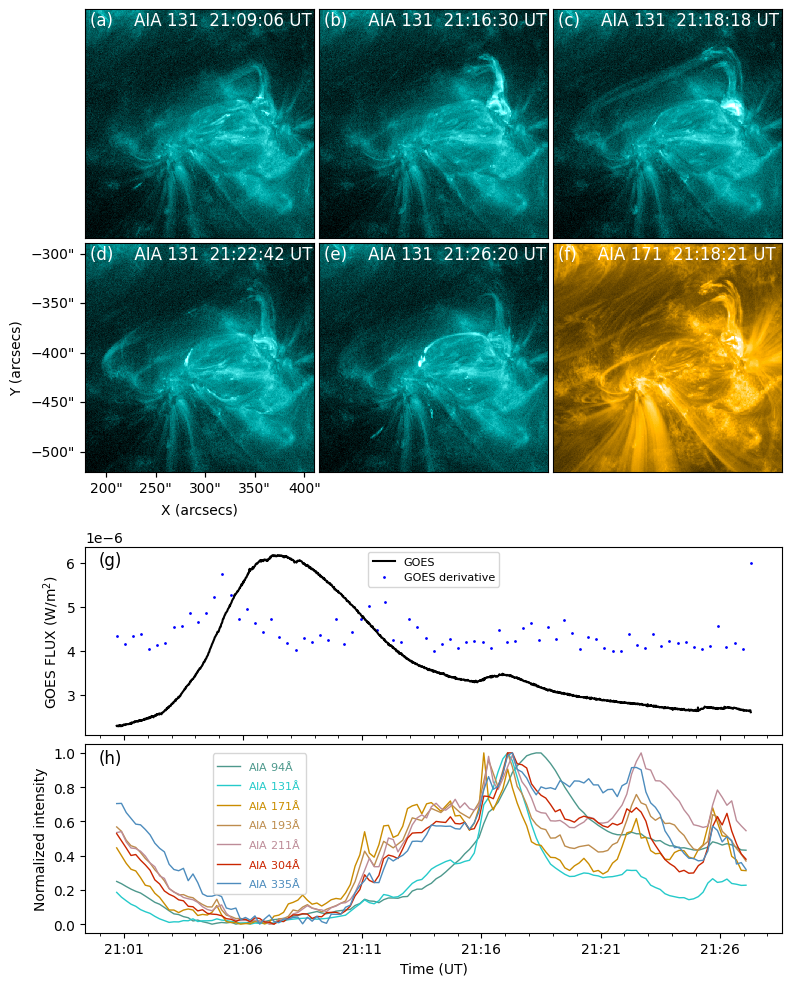

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(9,12))

# 整体划分为上下两大块：上(3份高度)，下(2份高度)
gs = gridspec.GridSpec(2, 1, height_ratios=[6, 5], hspace=0.175)

# ---------------- 上半部分：AIA 三幅图 ----------------
# 这里再细分成 1 行 3 列的小网格
gs_top = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[0], wspace=0.02,hspace=0.02)
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)

map_all=[map1,map2,map3,map4,map5,map6]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

ax_all=[]
for i in range(6):
    ax=fig.add_subplot(gs_top[i],projection=smap_all[i])
    ax_all.append(ax)
    #smap_all[i].plot(axes=ax)
    if i!=5:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=2000
        smap_all[i].plot(axes=ax,norm=old_norm)
    else:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=5000
        smap_all[i].plot(axes=ax,norm=old_norm)
    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第四张图加X Y轴
    if i == 3:   # 左下角
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X (arcsecs)')
        ax.set_ylabel('Y (arcsecs)')
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)       
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

ax_all[0].text(0.02,0.93,'(a)    AIA 131  21:09:06 UT',color='white',transform=ax_all[0].transAxes,fontsize=12)
ax_all[1].text(0.02,0.93,'(b)    AIA 131  21:16:30 UT',color='white',transform=ax_all[1].transAxes,fontsize=12)
ax_all[2].text(0.02,0.93,'(c)    AIA 131  21:18:18 UT',color='white',transform=ax_all[2].transAxes,fontsize=12)
ax_all[3].text(0.02,0.93,'(d)    AIA 131  21:22:42 UT',color='white',transform=ax_all[3].transAxes,fontsize=12)
ax_all[4].text(0.02,0.93,'(e)    AIA 131  21:26:20 UT',color='white',transform=ax_all[4].transAxes,fontsize=12)
ax_all[5].text(0.02,0.93,'(f)    AIA 171  21:18:21 UT',color='white',transform=ax_all[5].transAxes,fontsize=12)

# ---------------- 下半部分：两行共享x轴 ----------------
gs_bottom = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1], hspace=0.05)

ax8 = fig.add_subplot(gs_bottom[1])
ax7 = fig.add_subplot(gs_bottom[0],sharex=ax8)


from scipy.interpolate import splprep, splev
from scipy.ndimage import zoom
corr_x=np.zeros(6)
#第一个时刻对应21：00：42，最后一个时刻对应21：27：06
for i in range(len(corr_x)):
    corr_x[i]=(i*300+18)/12

#y为GOES值
goes_x=np.linspace(0,133,1585)
goes_y=ff.variables['irradiance_xrsb1'][75642:75642+1585]
#求导，缩并
dy_dx=np.gradient(goes_y,goes_x)
dy_dx_reduced=zoom(dy_dx,0.05)

ax7.plot(goes_x,goes_y,color='black',label='GOES')
der_goes=abs(dy_dx_reduced)
der_goes2=(der_goes-np.min(der_goes))/(np.max(der_goes)-np.min(der_goes))
ax7.scatter(np.linspace(0,133,len(dy_dx_reduced)),(der_goes2+2)*1e-6*2,color='blue',s=1,label='GOES derivative')
ax7.set_ylabel('GOES FLUX (W/m$^2$)')
ax7.text(0.02,0.90,'(g)',color='black',transform=ax7.transAxes,fontsize=12)
handles1, labels1 = ax7.get_legend_handles_labels()
ax7.legend(handles1, labels1, loc='upper center',fontsize=8)
ax7.tick_params(labelbottom=False)

name_list=['AIA 94$\mathrm{\AA}$','AIA 131$\mathrm{\AA}$',
           'AIA 171$\mathrm{\AA}$','AIA 193$\mathrm{\AA}$',
           'AIA 211$\mathrm{\AA}$','AIA 304$\mathrm{\AA}$','AIA 335$\mathrm{\AA}$']
lines=[]
linstyle=['-','-']

#从AIA那几个波段的cmap里采集颜色用来画曲线
color=[]
color_list=['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335']
for i in range(7):
    cmap=plt.get_cmap(color_list[i])
    middle_color=cmap(0.55)
    color.append(middle_color)

for i in range(7):
    line,=ax8.plot(intensity[i,:],color=color[i],label=name_list[i],linewidth=1,linestyle=linstyle[i%2])
    lines.append(line)
legend=ax8.legend(loc='center', bbox_to_anchor=(0.25, 0.58),fontsize=8)
for text,line in zip(legend.get_texts(),lines):
    text.set_color(line.get_color())

ax8.set_ylabel('Normalized intensity')
ax8.set_xticks(ticks=corr_x,labels=['21:01','21:06','21:11','21:16','21:21','21:26'])
ax8.text(0.02,0.9,'(h)',color='black',transform=ax8.transAxes,fontsize=12)
import matplotlib.ticker as ticker
ax8.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax8.yaxis.set_minor_locator(ticker.NullLocator())       # 禁止 y 轴小刻度
ax8.set_xlabel('Time (UT)')
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\aia_image_intensity_goes_curve.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

__DEM+time_distance__

DEM数据

In [11]:
time_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\\'+'*.fits')
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
avg_temp=np.zeros(58)
avg_em=np.zeros(58)
for i in range(58):
    datas=readsav(file_list[i*2+1])
    result=datas['result']
    smap_temp=result['SMAP_TEMP'][0]
    smap_em=result['SMAP_EM'][0]
    avg_temp[i]=np.mean(smap_temp[138:148,102:112])
    avg_em[i]=np.mean(smap_em[138:148,102:112])

时序图数据

5.149874071052627 4.8910559440820895 4.632244169727517
4.891058061620744
离太阳的距离是 151963569604.3406 m
一角秒对应多少千米是 736.7401757413695 km/arc
分辨率是 0.600697994 arc/pixel
尺寸是 2164.5785643123554 km/pixel
168.83712801636375
2.1645785643123556


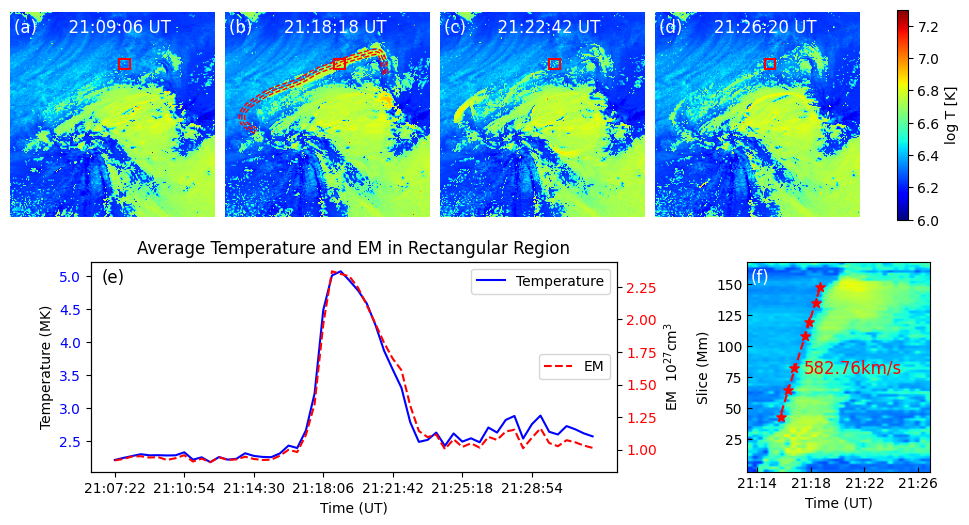

In [ ]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\fit_points.npz')
slice=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy')
a=data['fit_points']
b=data['fit_points2']
c=data['fit_points3']

#算一下距离，这里算的是平均距离，以像素为单位,时间间隔是12s*2=24s
dist1=np.average(np.sqrt(np.diff(a[:,0])**2+np.diff(a[:,1])**2))
dist2=np.average(np.sqrt(np.diff(b[:,0])**2+np.diff(b[:,1])**2))
dist3=np.average(np.sqrt(np.diff(c[:,0])**2+np.diff(c[:,1])**2))
print(dist1,dist2,dist3)
avg_diff=np.average([dist1,dist2,dist3])
print(avg_diff)

rsm=fits.open(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210044Z.131.image_lev1.fits')
dsun_obs=rsm[1].header['DSUN_OBS']
resolution=rsm[1].header['CDELT2']
#k是一角秒对应多少千米
k=sin(np.pi/(3600*180))*dsun_obs/1000
dist=k*resolution*avg_diff#实际上分辨率还要再除2
#dist=k*resolution*avg_diff*2#实际上分辨率还要再除2
print('离太阳的距离是',dsun_obs,'m')
print('一角秒对应多少千米是',k,'km/arc')
print('分辨率是',resolution,'arc/pixel')
print('尺寸是',dist,'km/pixel')

#接下来算一下纵坐标和横坐标的值
#dist单位是km/pixel avg_dist单位是pixel,除1000变成兆米，乘78是一共多长
print(dist*1e-3*78)
trans_coeff=dist*1e-3
print(trans_coeff)
corr_y=np.zeros(6)
for i in range(len(corr_y)):
    corr_y[i]=25*(i+1)/trans_coeff
    #corr_y[i]=50*(i+1)/trans_coeff
#32是第一个点，对应时间21：07：08
#98是第三十四个点，对应时间21：20：20
#算横轴时间的对应坐标
corr_x=np.zeros(4)
for i in range(len(corr_x)):
    corr_x[i]=(30+i*240)/24
fig=plt.figure(figsize=(12,6))
gs=gridspec.GridSpec(2,1,height_ratios=[1,1],hspace=0.2)

#图1
gs_top=gridspec.GridSpecFromSubplotSpec(1,4,subplot_spec=gs[0],wspace=0.05)
im_list=[]
ax11=fig.add_subplot(gs_top[0])
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
datas=readsav(file_list[10])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax11.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax11.text(0.02,0.9,'(a)      21:09:06 UT',color='white',transform=ax11.transAxes,fontsize=12)
plt.gca().add_patch(rect1)
plt.axis('off')



#图2
ax22=fig.add_subplot(gs_top[1])
datas=readsav(file_list[56])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax22.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax22.text(0.02,0.9,'(b)      21:18:18 UT',color='white',transform=ax22.transAxes,fontsize=12)
ax22.plot(b[:,1]/2,b[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(a[:,1]/2,a[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(c[:,1]/2,c[:,0]/2,linestyle='--',color='red',linewidth=1)
plt.gca().add_patch(rect1)
plt.axis('off')


#图3
ax3=fig.add_subplot(gs_top[2])
datas=readsav(file_list[78])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax3.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
ax3.text(0.02,0.9,'(c)      21:22:42 UT',color='white',transform=ax3.transAxes,fontsize=12)
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
plt.gca().add_patch(rect1)
plt.axis('off')

#图4
ax4=fig.add_subplot(gs_top[3])
datas=readsav(file_list[96])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax4.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax4.text(0.02,0.9,'(d)      21:26:20 UT',color='white',transform=ax4.transAxes,fontsize=12)
plt.gca().add_patch(rect1)
plt.axis('off')
#总的colorbar
cbar = fig.colorbar(im_list[0], ax=[ax11, ax22, ax3, ax4], 
                    orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('log T [K]')

#图5
#gs_bottom=gridspec.GridSpecFromSubplotSpec(1,2,subplot_spec=gs[1],width_ratios=[2,1],wspace=0.2,hspace=0.2)
gs_bottom=gridspec.GridSpecFromSubplotSpec(1,12,subplot_spec=gs[1],wspace=1.0,hspace=0.2)
ax1=fig.add_subplot(gs_bottom[1:8])
ax1.plot((avg_temp[:56])/1e6,'b-',label='Temperature')
ax1.set_xlabel('Time (UT)')
ax1.set_ylabel('Temperature (MK)')
labels_arr=[]
#设置xticks
for i in range(0,56,8):
    labels_arr.append(file_list[i*2+1][-12:-4].replace("_",":"))
ax1.set_xticks(ticks=np.arange(0,56,8),labels=labels_arr)
ax1.tick_params(axis='y',labelcolor='b')
ax2=ax1.twinx()
ax2.plot(avg_em[:56]/1e27,'r--',label='EM')
ax2.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax2.tick_params(axis='y',labelcolor='r')
ax1.legend(loc='upper right')
ax2.legend(loc='center right')
# 显示图形
ax1.text(0.02,0.9,'(e)',color='black',transform=ax1.transAxes,fontsize=12)
plt.title('Average Temperature and EM in Rectangular Region',size=12)

#图6
ax5=fig.add_subplot(gs_bottom[9:])
ax5.imshow(np.log10(slice),cmap='jet',origin='lower',vmin=6.0,vmax=7.3,aspect=0.5)
coord=[(5.8,20),(7,30),(8.2,38),(10.2,50),(11,55),(12.2,62),(13,68)]
x1,y1=zip(*coord)
x1,y1=np.array(x1),np.array(y1)
ax5.scatter(x=x1,y=y1,c='red',marker='*',s=50)
coeff1=np.polyfit(x1,y1,1)
poly1=np.poly1d(coeff1)
ax5.text(10,36,'582.76km/s',fontsize=12,color='red')
ax5.set_yticks(ticks=corr_y,labels=['25','50','75','100','125','150'])
#ax5.set_yticks(ticks=corr_y,labels=['50','100','150','200','250','300'])
ax5.set_ylabel('Slice (Mm)')
ax5.set_xlabel('Time (UT)')
ax5.set_xticks(ticks=corr_x,labels=['21:14','21:18','21:22','21:26'])
ax5.plot(x1,poly1(x1),c='red',linestyle='--')
ax5.tick_params(axis='both',direction='in')
ax5.text(0.02,0.9,'(f)',color='white',transform=ax5.transAxes,fontsize=12)
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\DEM_time_distance.pdf',format='pdf', bbox_inches='tight')

In [17]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\program\temp.npy')

之前的一部分

In [ ]:
fig=plt.figure(figsize=(12,6))
gs=gridspec.GridSpec(2,1,height_ratios=[1,1],hspace=0.2)

#图1
gs_top=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[0],wspace=0.2)

ax11=fig.add_subplot(gs_top[0])
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
datas=readsav(file_list[10])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
plt.imshow(np.log10(smap_temp),cmap='jet',origin='lower')
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=2)
plt.gca().add_patch(rect1)
plt.axis('off')
plt.title('21:09:06')

#图2
ax22=fig.add_subplot(gs_top[1])
datas=readsav(file_list[56])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
plt.imshow(np.log10(smap_temp),cmap='jet',origin='lower')
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=2)
plt.gca().add_patch(rect1)
plt.axis('off')
plt.title('21:18:18')

#图3
ax3=fig.add_subplot(gs_top[2])
datas=readsav(file_list[71])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
plt.imshow(np.log10(smap_temp),cmap='jet',origin='lower')
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=2)
plt.gca().add_patch(rect1)
plt.axis('off')
plt.title('21:21:18')

#图4
gs_bottom=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[1],wspace=0.4,hspace=0.2)
ax1=fig.add_subplot(gs_bottom[0:2])
ax1.plot((avg_temp[:56])/1e6,'b-',label='Temperature')
ax1.set_xlabel('Time(UT)')
ax1.set_ylabel('Temperature(MK)')
labels_arr=[]
#设置xticks
for i in range(0,56,9):
    labels_arr.append(file_list[i*2+1][-12:-4].replace("_",":"))
ax1.set_xticks(ticks=np.arange(0,56,8),labels=labels_arr)
ax1.tick_params(axis='y',labelcolor='b')
ax2=ax1.twinx()
ax2.plot(avg_em[:56]/1e27,'r--',label='EM')
ax2.set_ylabel('EM  '+ r'$10^{27} \text{cm}^3$')
ax2.tick_params(axis='y',labelcolor='r')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
# 显示图形

plt.title('Average Temperature and EM in Rectangular Region',size=12)

#图5
ax5=fig.add_subplot(gs_bottom[2])
ax5.imshow(np.log10(slice),cmap='jet',origin='lower',vmin=6.0,vmax=7.3,aspect=0.5)
coord=[(5.8,20),(7,30),(8.2,38),(10.2,50),(11,55),(12.2,62),(13,68)]
x1,y1=zip(*coord)
x1,y1=np.array(x1),np.array(y1)
ax5.scatter(x=x1,y=y1,c='red',marker='*',s=50)
coeff1=np.polyfit(x1,y1,1)
poly1=np.poly1d(coeff1)
ax5.text(10,36,'582.76km/s',fontsize=12,color='red')
ax5.set_yticks(ticks=corr_y,labels=['25','50','75','100','125','150'])
ax5.set_ylabel('Slice(Mm)')
ax5.set_xticks(ticks=corr_x,labels=['21:08','21:12','21:16','21:20'])
ax5.plot(x1,poly1(x1),c='red',linestyle='--')
ax5.tick_params(axis='both',direction='in')
#plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\DEM_analysis.pdf',format='pdf', bbox_inches='tight')

__三、IRIS图像__

In [3]:
solar_xy=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\solar_xy.sav')
print(solar_xy.keys())
solar_x=solar_xy['solar_x']
solar_y=solar_xy['solar_y']

dict_keys(['solar_x', 'solar_y'])


In [31]:
all_sji_image=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_nonth.npz')
doppler_vel_all=data['doppler_vel_all']
sigma_vel_nonth=data['sigma_vel_nonth']
vel_all2 = np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\vel_all.npy', allow_pickle=True)
vel_all=vel_all2.item()

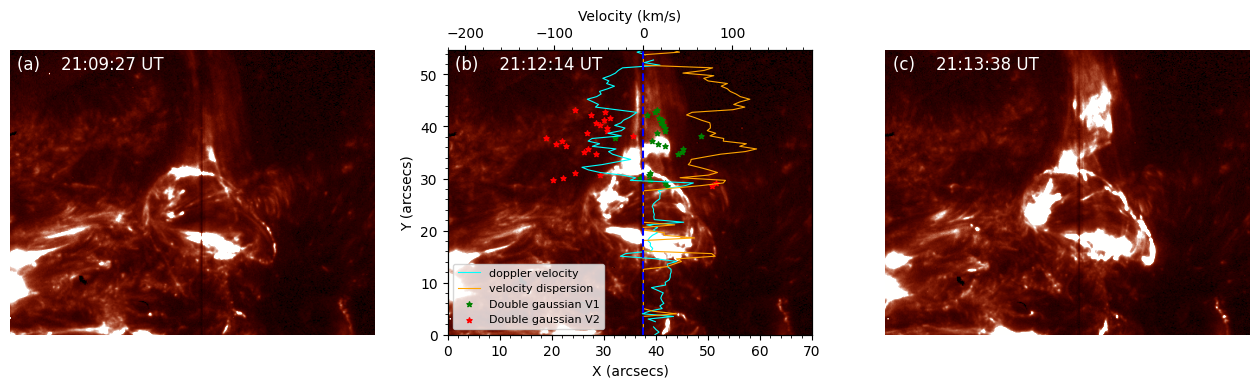

In [61]:
fig=plt.figure(figsize=(16,5))
gs=gridspec.GridSpec(1,3,wspace=0.2)
ax0=fig.add_subplot(gs[0])
ax1=fig.add_subplot(gs[1])
ax2=fig.add_subplot(gs[2])

#图（a）
ax0.imshow(all_sji_image[799][0][300:,:],cmap='irissji1400',vmin=0,vmax=20,
           origin='lower',extent=[0,422*0.166,0,330*0.166])
ax0.set_axis_off()
ax0.text
ax0.text(0.02,0.93,'(a)    21:09:27 UT',color='white',transform=ax0.transAxes,fontsize=12)

#图（b）
fig_data=all_sji_image[807][0][300:,:]
ax1.imshow(fig_data,cmap='irissji1400',vmin=0,vmax=20,origin='lower',
           extent=[0,422*0.166,0,330*0.166])
ax1.set_xlabel('X (arcsecs)')
ax1.set_ylabel('Y (arcsecs)')
ax1.minorticks_on()
# 设置所有子图保持相同的宽高比
pos1 = ax1.get_position()
up_ax = ax1.twiny()
# 重新把 ax1 和 up_ax 的位置都设成一样的矩形
ax1.set_position(pos1)
up_ax.set_position(pos1)
y_vals=np.linspace(0,330*0.166,110)
#单高斯曲线
kk=403
cnt=kk-398
up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
up_ax.plot(sigma_vel_nonth[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
up_ax.set_xlim(-220,190)
up_ax.set_xlabel('Velocity (km/s)')
up_ax.minorticks_on()
up_ax.axvline(0,color='blue',linestyle='--')
#画双高斯拟合的散点图
row=np.sum(vel_all[kk*2+1][:,4]==1)
double_scatter=np.zeros((row,3))
cnt=0
for i in range(110):
    if vel_all[kk*2+1][i,4]==1:
        double_scatter[cnt,0]=vel_all[kk*2+1][i,0]
        double_scatter[cnt,1]=vel_all[kk*2+1][i,2]
        double_scatter[cnt,2]=y_vals[i]
        cnt=cnt+1
up_ax.scatter(double_scatter[:,0],double_scatter[:,2],
            label='Double gaussian V1',s=15,
            color='green',marker='*')
up_ax.scatter(double_scatter[:,1],double_scatter[:,2],
            label='Double gaussian V2',s=15,
            color='red',marker='*')
up_ax.legend(loc='lower left',fontsize=8)
ax1.text(0.02,0.93,'(b)    21:12:14 UT',color='white',transform=ax1.transAxes,fontsize=12)

#图（c）
ax2.imshow(all_sji_image[811][0][300:,:],cmap='irissji1400',vmin=0,vmax=20,
           origin='lower',extent=[0,422*0.166,0,330*0.166])
ax2.set_axis_off()
ax2.text(0.02,0.93,'(c)    21:13:38 UT',color='white',transform=ax2.transAxes,fontsize=12)
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\three_iris.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

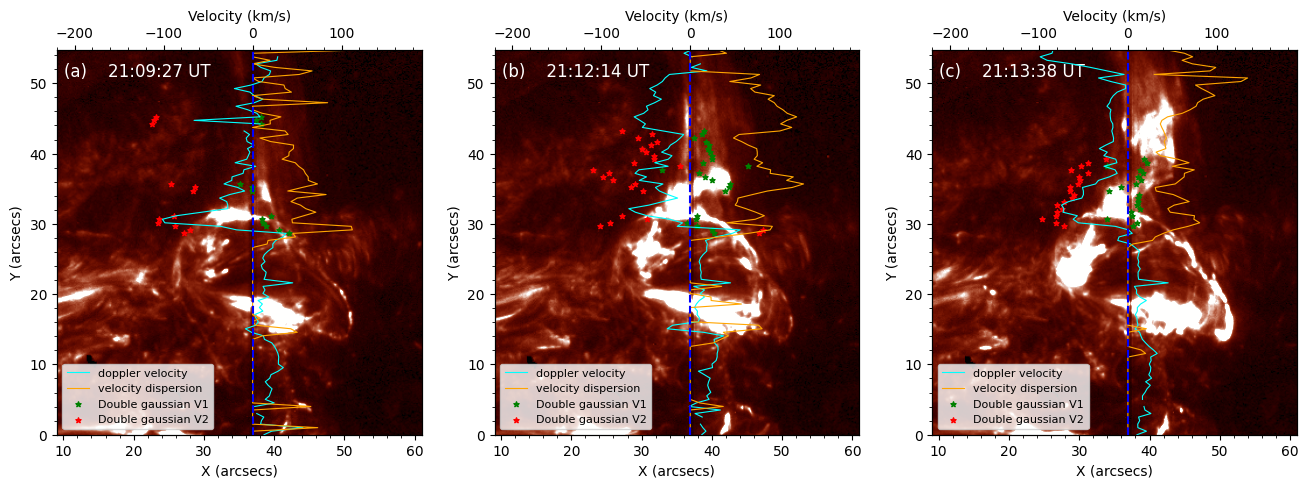

In [68]:
fig=plt.figure(figsize=(16,5))
gs=gridspec.GridSpec(1,3,wspace=0.2)
ax_all=[]
for i in range(3):
    ax=fig.add_subplot(gs[i])
    ax_all.append(ax)

list1=[799,807,811]
list2=[399,403,405]
list3=['(a)    21:09:27 UT','(b)    21:12:14 UT','(c)    21:13:38 UT']
for i in range(3):
    ax=ax_all[i]
    ax.imshow(all_sji_image[list1[i]][0][300:,:],cmap='irissji1400',vmin=0,vmax=20,
              origin='lower',extent=[0,422*0.166,0,330*0.166])
    ax.set_xlabel('X (arcsecs)')
    ax.set_ylabel('Y (arcsecs)')
    ax.minorticks_on()
    pos=ax.get_position()
    up_ax=ax.twiny()
    y_vals=np.linspace(0,330*0.166,110)
    kk=list2[i]
    cnt=kk-398
    up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
    up_ax.plot(sigma_vel_nonth[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
    up_ax.set_xlim(-220,190)
    up_ax.set_xlabel('Velocity (km/s)')
    up_ax.minorticks_on()
    up_ax.axvline(0,color='blue',linestyle='--')
    #画双高斯拟合的散点图
    row=np.sum(vel_all[kk*2+1][:,4]==1)
    double_scatter=np.zeros((row,3))
    cnt=0
    ax.text(0.02,0.93,list3[i],color='white',transform=ax.transAxes,fontsize=12)
    for j in range(110):
        if vel_all[kk*2+1][j,4]==1:
            double_scatter[cnt,0]=vel_all[kk*2+1][j,0]
            #print(double_scatter[cnt,0])
            double_scatter[cnt,1]=vel_all[kk*2+1][j,2]
            double_scatter[cnt,2]=y_vals[j]
            cnt=cnt+1
    up_ax.scatter(double_scatter[:,0],double_scatter[:,2],
                label='Double gaussian V1',s=15,
                color='green',marker='*')
    up_ax.scatter(double_scatter[:,1],double_scatter[:,2],
                label='Double gaussian V2',s=15,
                color='red',marker='*')
    up_ax.legend(loc='lower left',fontsize=8)
    #加图标
    
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\three_iris_all.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

In [ ]:
fig=plt.figure(figsize=(16,5))
gs=gridspec.GridSpec(1,3,wspace=0.2)
ax0=fig.add_subplot(gs[0])
ax1=fig.add_subplot(gs[1])
ax2=fig.add_subplot(gs[2])

#图（a）
ax0.imshow(all_sji_image[799][0][300:,:],cmap='irissji1400',vmin=0,vmax=20,
           origin='lower',extent=[0,422*0.166,0,330*0.166])
ax0.set_axis_off()
ax0.text(0.02,0.93,'(a)    21:09:27 UT',color='white',transform=ax0.transAxes,fontsize=12)

#图（b）
fig_data=all_sji_image[807][0][300:,:]
ax1.imshow(fig_data,cmap='irissji1400',vmin=0,vmax=20,origin='lower',
           extent=[0,422*0.166,0,330*0.166])
ax1.set_xlabel('X (arcsecs)')
ax1.set_ylabel('Y (arcsecs)')
ax1.minorticks_on()
# 设置所有子图保持相同的宽高比
pos1 = ax1.get_position()
up_ax = ax1.twiny()
# 重新把 ax1 和 up_ax 的位置都设成一样的矩形
ax1.set_position(pos1)
up_ax.set_position(pos1)
y_vals=np.linspace(0,330*0.166,110)
#单高斯曲线
kk=403
cnt=kk-398
up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
up_ax.plot(sigma_vel_nonth[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
up_ax.set_xlim(-220,190)
up_ax.set_xlabel('Velocity (km/s)')
up_ax.minorticks_on()
up_ax.axvline(0,color='blue',linestyle='--')
#画双高斯拟合的散点图
row=np.sum(vel_all[kk*2+1][:,4]==1)
double_scatter=np.zeros((row,3))
cnt=0
for i in range(110):
    if vel_all[kk*2+1][i,4]==1:
        double_scatter[cnt,0]=vel_all[kk*2+1][i,0]
        double_scatter[cnt,1]=vel_all[kk*2+1][i,2]
        double_scatter[cnt,2]=y_vals[i]
        cnt=cnt+1
up_ax.scatter(double_scatter[:,0],double_scatter[:,2],
            label='Double gaussian V1',s=15,
            color='green',marker='*')
up_ax.scatter(double_scatter[:,1],double_scatter[:,2],
            label='Double gaussian V2',s=15,
            color='red',marker='*')
up_ax.legend(loc='lower left',fontsize=8)
ax1.text(0.02,0.93,'(b)    21:12:14 UT',color='white',transform=ax1.transAxes,fontsize=12)

#图（c）
ax2.imshow(all_sji_image[811][0][300:,:],cmap='irissji1400',vmin=0,vmax=20,
           origin='lower',extent=[0,422*0.166,0,330*0.166])
ax2.set_axis_off()
ax2.text(0.02,0.93,'(c)    21:13:38 UT',color='white',transform=ax2.transAxes,fontsize=12)
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\three_iris_all.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)